<a href="https://colab.research.google.com/github/kat-miao/CUNY-Data-Analytics/blob/main/Project_2_Public_Health.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Question: Who spends the most amount of time in the hospital?



In [2]:
# importing all the libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plot
import seaborn as sns
%matplotlib inline

In [3]:
# df can be named into anything to reference the data
phdf= pd.read_csv('https://raw.githubusercontent.com/niteen11/DataAnalyticsAcademy/master/Python/dataset_diabetes/diabetic_data.csv')

Viewing structure of data

In [7]:
#preview of data
phdf.head(20)

,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
5,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30
6,55842,84259809,Caucasian,Male,[60-70),?,3,1,2,4,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
7,63768,114882984,Caucasian,Male,[70-80),?,1,1,7,5,...,No,No,No,No,No,No,No,No,Yes,>30
8,12522,48330783,Caucasian,Female,[80-90),?,2,1,4,13,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
9,15738,63555939,Caucasian,Female,[90-100),?,3,3,4,12,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


In [6]:
#seeing structure of the data and column names
phdf.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   encounter_id              101766 non-null  int64 
 1   patient_nbr               101766 non-null  int64 
 2   race                      101766 non-null  object
 3   gender                    101766 non-null  object
 4   age                       101766 non-null  object
 5   weight                    101766 non-null  object
 6   admission_type_id         101766 non-null  int64 
 7   discharge_disposition_id  101766 non-null  int64 
 8   admission_source_id       101766 non-null  int64 
 9   time_in_hospital          101766 non-null  int64 
 10  payer_code                101766 non-null  object
 11  medical_specialty         101766 non-null  object
 12  num_lab_procedures        101766 non-null  int64 
 13  num_procedures            101766 non-null  int64 
 14  num_

In [5]:
#seeing some of the stats
phdf.describe()

,encounter_id,patient_nbr,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,1.017660e+05,1.017660e+05,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000,101766.000000
mean,1.652016e+08,5.433040e+07,2.024006,3.715642,5.754437,4.395987,43.095641,1.339730,16.021844,0.369357,0.197836,0.635566,7.422607
std,1.026403e+08,3.869636e+07,1.445403,5.280166,4.064081,2.985108,19.674362,1.705807,8.127566,1.267265,0.930472,1.262863,1.933600
min,1.252200e+04,1.350000e+02,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,8.496119e+07,2.341322e+07,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.523890e+08,4.550514e+07,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,2.302709e+08,8.754595e+07,3.000000,4.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,4.438672e+08,1.895026e+08,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


Filtering data

In [28]:
#creating subset of columns to narrow down on dataset
phdf_subset = phdf[["race", "gender", "time_in_hospital"]]
phdf_subset.head(20)

,race,gender,time_in_hospital
0,Caucasian,Female,1
1,Caucasian,Female,3
2,AfricanAmerican,Female,2
3,Caucasian,Male,2
4,Caucasian,Male,1
5,Caucasian,Male,3
6,Caucasian,Male,4
7,Caucasian,Male,5
8,Caucasian,Female,13
9,Caucasian,Female,12


In [29]:
#remove unwanted "?" values
phdf["race"] = phdf["race"].replace("?", np.nan)

In [30]:
#checking to see if data loaded
phdf_subset.head(21)

,race,gender,time_in_hospital
0,Caucasian,Female,1
1,Caucasian,Female,3
2,AfricanAmerican,Female,2
3,Caucasian,Male,2
4,Caucasian,Male,1
5,Caucasian,Male,3
6,Caucasian,Male,4
7,Caucasian,Male,5
8,Caucasian,Female,13
9,Caucasian,Female,12


Analyzing data

In [38]:
#grouping function to summarize data and sort by highest value
phdf_subset.groupby(["gender", "race"])["time_in_hospital"].mean().sort_values(ascending=False)

gender           race           
Female           AfricanAmerican    4.541269
                 Caucasian          4.481443
Male             AfricanAmerican    4.455493
                 Other              4.298547
                 Caucasian          4.281379
Female           Other              4.252674
Male             Asian              4.089783
Female           Hispanic           4.086081
Male             Hispanic           4.029630
Female           Asian              3.899371
Unknown/Invalid  Other              1.000000
Name: time_in_hospital, dtype: float64

In [57]:
#unstack data to prepare for visualization and rename function
plot_data = phdf_subset.groupby(["gender", "race"])["time_in_hospital"].mean().sort_values(ascending=False).unstack()

<Axes: title={'center': 'Time in Hospital by Race and Gender'}, xlabel='race', ylabel='time in hospital (days)'>

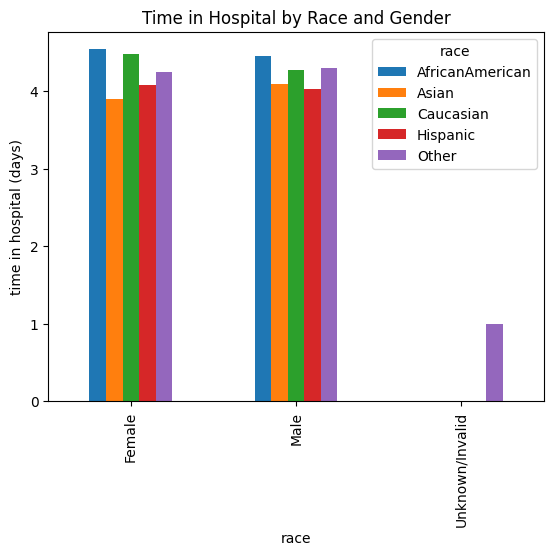

In [58]:
#graphing data to see who spends the most time in the hospital
plot_data.plot(
    kind = "bar",
    xlabel = "race",
    ylabel = "time in hospital (days)",
    title = "Time in Hospital by Race and Gender"
)

In [48]:
#not the kind of graph I was looking for
#have to reverse column order to get race at the x-axis and gender in the legend
plot_data_2 = phdf_subset.groupby(["race", "gender"])["time_in_hospital"].mean().sort_values(ascending=False).unstack()

<Axes: title={'center': 'Time in Hospital by Race and Gender'}, xlabel='race', ylabel='time in hospital (days)'>

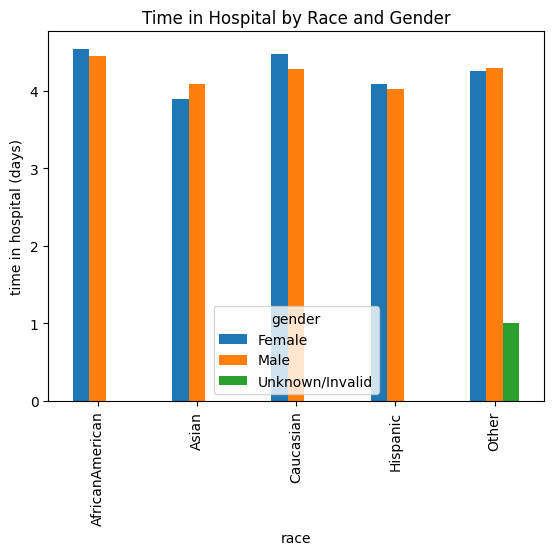

In [49]:
#replotting data in bar graph
plot_data_2.plot(
    kind = "bar",
    xlabel = "race",
    ylabel = "time in hospital (days)",
    title = "Time in Hospital by Race and Gender"
)

Conclusion: Based on the visualization of the data, it looks like Asian women spend the least amount of time in the hospital while Black women spend the most amount of time in the hospital. However, I was wondering about the count of each race/gender in each quality.

In [55]:
#copied and pasted plot data function to analyze by count and not mean.
plot_data_count = phdf_subset.groupby(["race", "gender"])["time_in_hospital"].count().sort_values(ascending=False).unstack()

<Axes: title={'center': 'Time in Hospital by Race and Gender'}, xlabel='race', ylabel='time in hospital (days)'>

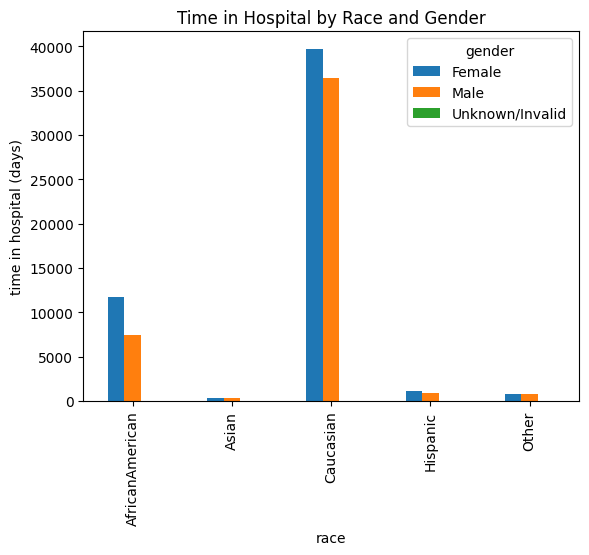

In [56]:
#graphing new count data
plot_data_count.plot(
    kind = "bar",
    xlabel = "race",
    ylabel = "time in hospital (days)",
    title = "Time in Hospital by Race and Gender"
)

Conclusion: Even though it looks like Asian women spend the least amount of time in the hospital while Black women spend the most amount of time in the hospital, the sample data of people across race and gender is not evenly distributed because Caucasian (white) male and females are overly represented in this dataset, so my initial conclusion needs more investigating.
